# Autonomous Drone Rescue Using Dynamic Programming

Notebook skeleton with explanations and pseudocode only.


## 1. Objective

Design a finite MDP for autonomous rescue drone navigation.

Goals:
- Rescue civilians
- Avoid danger zones
- Manage battery
- Reach charging stations
- Solve using Dynamic Programming


In [70]:
GROUP_ID = 87






## 2. Problem Formulation as an MDP

Define:

State Space S
Action Space A
Transition Function P
Reward Function R
Discount Factor gamma


In [71]:
# State Representation

# state = (
#     row,
#     col,
#     battery,
#     rescue_status
# )

# Example:
# (2,1,8,(0,1))


## 3. Environment Configuration

Define:

- Start position
- Rescue targets
- Danger zones
- Charging stations
- Wind zones
- Obstacles


In [72]:
# Determine grid size, battery and wind probability:
# As group ends with 7, we fall in the condition group ID ends with 5–9 defined in the problem statement. So, we will use the following.
# Grid size of 6x6
# Wind probability of 30%.
# 3 rescue targets, 2 charging stations, 4 danger zones, 3 blocked cells
# As group is ends with an odd digit (7), as mentioned in problem statement, maximum battery = 15 units
# Maximum steps allowed is 75 for 6×6 grids.
GRID_SIZE = 6
WIND_PROBABILITY = 0.3
NUM_RESCUE_TARGETS = 3
NUM_CHARGING_STATIONS = 2
NUM_DANGER_ZONES = 4
NUM_BLOCKED_CELLS = 3
MAX_BATTERY = 15
MAX_STEPS = 75

# Our custom Grid
# Symbol vs Meaning 
# S Start position 
# F Free/Safe cell 
# D Dangerous zone 
# R Rescue target 
# C Charging station 
# W Wind zone 
# X Blocked cell / obstacle
 

GRID = [
    ['S', 'F', 'W', 'F', 'R', 'F'],
    ['F', 'X', 'F', 'D', 'F', 'F'],
    ['F', 'F', 'C', 'F', 'F', 'X'],
    ['D', 'F', 'X', 'F', 'W', 'R'],
    ['F', 'F', 'D', 'F', 'F', 'F'],
    ['R', 'F', 'W', 'F', 'D', 'C'],
]



## 4. Environment Skeleton

Implement:
- reset()
- step(action)
- render()


In [73]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

class DroneRescueEnvironment:

    def __init__(self, grid, grid_size, wind_probability, init_battery_of_drone, max_battery_of_drone):
        self.grid = grid
        self.grid_size = grid_size
        self.wind_probability = wind_probability
        self.init_battery = init_battery_of_drone
        self.max_battery = max_battery_of_drone
        self.drone_position = self.find_start_position()
        self.drone_battery = init_battery_of_drone

        self.rescue_targets = [
            (i, j)
            for i in range(self.grid_size)
            for j in range(self.grid_size)
            if self.grid[i][j] == 'R'
        ]
        self.rescue_index = {pos: idx for idx, pos in enumerate(self.rescue_targets)}
        self.full_rescue_mask = (1 << len(self.rescue_targets)) - 1

    def step(self, action):
        # TODO
        # consume battery
        # apply movement
        # apply wind
        # calculate reward
        # update rescue
        pass

    def render(self):
        cmap = {'S': 0, 'F': 1, 'W': 2, 'R': 3, 'C': 4, 'D': 5, 'X': 6}
        labels = {0: 'S', 1: 'F', 2: 'W', 3: 'R', 4: 'C', 5: 'D', 6: 'X'}
        colors = ['lightgreen', 'lightgrey', 'skyblue', 'orange', 'yellow', 'salmon', 'brown']

        grid_map = np.array([[cmap[cell] for cell in row] for row in self.grid])

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid_map, cmap=mcolors.ListedColormap(colors), origin='upper')

        for i in range(self.grid_size):
            for j in range(self.grid_size):
                label = labels[grid_map[i, j]]
                if (i, j) == self.drone_position:
                    label = '*'  # Mark drone position with an asterisk
                ax.text(j, i, label, ha='center', va='center', color='black', fontsize=14, fontweight='bold')

        ax.set_axis_off()
        ax.set_title(f"Drone position: {self.drone_position} | battery: {self.drone_battery}")
        plt.show()

    def find_start_position(self):
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                if self.grid[i][j] == 'S':
                    return (i, j)
        raise ValueError("Start position 'S' not found in the grid.")

    def getPossibleActions(self, state):
        if len(state) == 4:
            x, y, battery, _ = state
            if battery <= 0:
                return ()
        else:
            x, y = state

        actions = ('hover',)
        if x > 0:
            actions += ('left',)
        if x < self.grid_size - 1:
            actions += ('right',)
        if y > 0:
            actions += ('up',)
        if y < self.grid_size - 1:
            actions += ('down',)
        return actions

    def getReward(self, state, action, next_state):
        x, y, battery, mask = state
        next_x, next_y, next_battery, next_mask = next_state

        REWARD_RESCUE_TARGET = 20
        PENALTY_ENTER_DANGER_ZONE = -10
        PENALTY_BATTERY_EXHAUSTED = -20
        REWARD_CHARGING_STATION = 5
        PENALTY_REGULAR_MOVEMENT = -1

        reward = 0
        if (next_x, next_y) != (x, y):
            reward += PENALTY_REGULAR_MOVEMENT

        next_cell = self.grid[next_x][next_y]
        if next_cell == 'R':
            if (next_x, next_y) in self.rescue_index:
                rescue_bit = 1 << self.rescue_index[(next_x, next_y)]
                if not (mask & rescue_bit):
                    reward += REWARD_RESCUE_TARGET
        elif next_cell == 'D':
            reward += PENALTY_ENTER_DANGER_ZONE
        elif next_cell == 'C':
            reward += REWARD_CHARGING_STATION

        if battery > 0 and next_battery == 0 and next_cell != 'C':
            reward += PENALTY_BATTERY_EXHAUSTED

        return reward

    def _position(self, state):
        return state[:2] if len(state) == 4 else state

    def _move_result(self, state, action):
        x, y = self._position(state)
        if action == 'hover':
            return (x, y)
        if action == 'left':
            nx, ny = x - 1, y
        elif action == 'right':
            nx, ny = x + 1, y
        elif action == 'up':
            nx, ny = x, y - 1
        elif action == 'down':
            nx, ny = x, y + 1
        else:
            return (x, y)

        if nx < 0 or nx >= self.grid_size or ny < 0 or ny >= self.grid_size:
            return (x, y)
        if self.grid[nx][ny] == 'X':
            return (x, y)
        return (nx, ny)

    def _next_state(self, state, next_pos):
        x, y, battery, mask = state
        if battery <= 0:
            return state

        next_x, next_y = next_pos
        next_cell = self.grid[next_x][next_y]

        if next_cell == 'C':
            next_battery = self.max_battery
        else:
            next_battery = max(battery - 1, 0)

        next_mask = mask
        if next_cell == 'R' and (next_x, next_y) in self.rescue_index:
            next_mask |= 1 << self.rescue_index[(next_x, next_y)]

        return (next_x, next_y, next_battery, next_mask)

    def _transitions(self, state, action):
        if state[2] <= 0 or state[3] == self.full_rescue_mask:
            return [(1.0, state)]

        cell = self.grid[state[0]][state[1]]
        actions = self.getPossibleActions(state)

        if cell == 'W' and actions:
            probs = []
            for a in actions:
                p = 0.0
                if a == action:
                    p += 1.0 - self.wind_probability
                p += self.wind_probability / len(actions)
                next_pos = self._move_result(state, a)
                probs.append((p, self._next_state(state, next_pos)))

            combined = {}
            for p, ns in probs:
                combined[ns] = combined.get(ns, 0) + p
            return [(p, ns) for ns, p in combined.items()]

        return [(1.0, self._next_state(state, self._move_result(state, action)))]

    def value_iteration(self, gamma=0.99, tol=1e-4, max_iters=1000, visualize=True):
        positions = [
            (i, j)
            for i in range(self.grid_size)
            for j in range(self.grid_size)
            if self.grid[i][j] != 'X'
        ]
        masks = range(1 << len(self.rescue_targets))
        states = [
            (x, y, battery, mask)
            for x, y in positions
            for battery in range(self.max_battery + 1)
            for mask in masks
        ]

        V = {s: 0.0 for s in states}
        policy = {}

        for it in range(max_iters):
            delta = 0.0
            V_new = V.copy()

            for s in states:
                if s[2] == 0 or s[3] == self.full_rescue_mask:
                    continue

                actions = self.getPossibleActions(s)
                if not actions:
                    continue

                best_q = -np.inf
                best_a = actions[0]

                for a in actions:
                    q = 0.0
                    for p, ns in self._transitions(s, a):
                        r = self.getReward(s, a, ns)
                        q += p * (r + gamma * V[ns])

                    if q > best_q:
                        best_q = q
                        best_a = a

                V_new[s] = best_q
                policy[s] = best_a
                delta = max(delta, abs(V_new[s] - V[s]))

            V = V_new
            if delta < tol:
                print(f'Value iteration converged in {it + 1} iterations (delta={delta:.6f})')
                break
        else:
            print('Value iteration reached max iterations')

        if visualize:
            value_grid = np.full((self.grid_size, self.grid_size), np.nan)
            for x, y in positions:
                values = [V[s] for s in states if s[0] == x and s[1] == y]
                if values:
                    value_grid[x, y] = max(values)

            plt.figure(figsize=(6, 6))
            plt.imshow(value_grid, cmap='viridis', origin='upper')
            plt.colorbar(label='Value')
            for i in range(self.grid_size):
                for j in range(self.grid_size):
                    if not np.isnan(value_grid[i, j]):
                        plt.text(j, i, f'{value_grid[i, j]:.1f}', ha='center', va='center', color='white', fontsize=9)
            plt.title('Optimal State-Value Function (positions)')
            plt.show()

        return V, policy

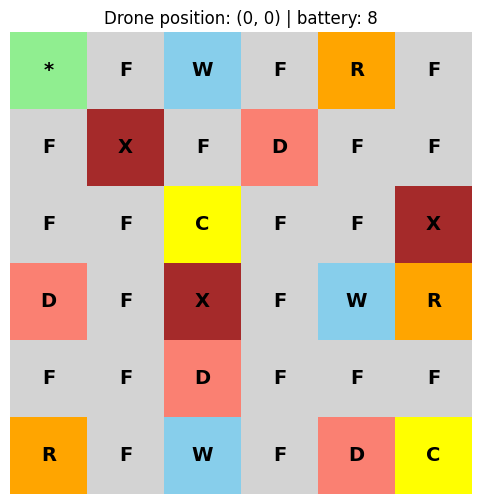

Value iteration converged in 39 iterations (delta=0.091240)


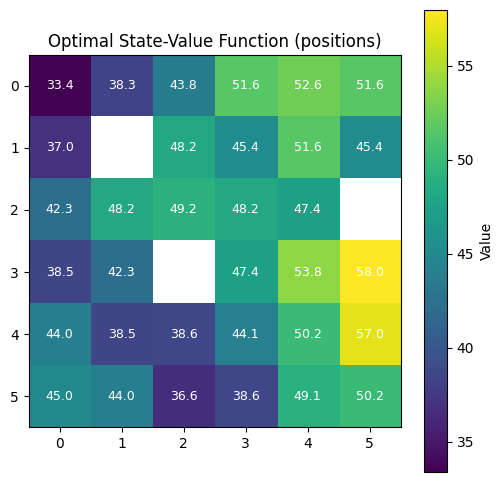

Computed DP over full states: 4224 values


In [74]:
dre = DroneRescueEnvironment(GRID, GRID_SIZE, WIND_PROBABILITY, 8, MAX_BATTERY)
dre.render()
V, policy = dre.value_iteration(gamma=0.9, tol=1e-1, max_iters=1000, visualize=True)
print("Computed DP over full states:", len(V), "values")